# Cross-encoder aligner evaluation: all four aligners x three sample sizes x two teachers

Evaluates the four ModernBERT CrossEncoder aligners (schedule, activity,
vehicle-ownership, profile-coherence) trained by `scripts/run_cross_encoder_eval.py`
at sample sizes 100 / 1000 / 10000, each with an 80/20 stratified train/test split,
labeled by both the Qwen and Mistral teachers served at the same sibling endpoint.

This notebook only loads and reports the results the driver script already computed
(`data/eval/cross_encoders/results.parquet` and per-combo prediction parquets) — it
does not itself run labeling or training, since that sweep can take hours. See
`notebooks/06_cross_reranker_evaluation/01_profile_coherence_evaluation.ipynb` for
the original single-aligner evaluation this one supersedes in scope (all four
aligners, all three sample sizes, both teachers) but not in per-example diagnostics.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if not (repo_root / 'pyproject.toml').exists():
    raise FileNotFoundError('Run this notebook from inside the citybehavex repository.')

DATA_ROOT = repo_root / 'data/eval/cross_encoders'
RESULTS_PATH = DATA_ROOT / 'results.parquet'
OUTPUT_DIR = repo_root / 'notebooks/06_cross_reranker_evaluation/outputs/multi_aligner'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALIGNERS = ['schedule', 'activity', 'vehicle_ownership', 'profile_coherence']
SAMPLE_SIZES = [100, 1000, 10000]
TEACHERS = ['qwen', 'mistral']


## Coverage: which (aligner, teacher, sample_size) combos are done

In [3]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f'{RESULTS_PATH} does not exist yet. Run scripts/run_cross_encoder_eval.py first '
        '(once per teacher currently served at the sibling endpoint).'
    )

results = pd.read_parquet(RESULTS_PATH)
print(f'Loaded {len(results)} result rows.')

coverage = pd.DataFrame(
    index=pd.MultiIndex.from_product([ALIGNERS, SAMPLE_SIZES], names=['aligner', 'sample_size']),
    columns=TEACHERS,
).fillna(False)
for _, row in results.iterrows():
    if row['aligner'] in ALIGNERS and row['teacher'] in TEACHERS and row['sample_size'] in SAMPLE_SIZES:
        coverage.loc[(row['aligner'], row['sample_size']), row['teacher']] = True
display(coverage)

missing = coverage[~coverage.all(axis=1)]
if len(missing):
    print(f'{len(missing)} combo(s) not yet complete for both teachers:')
    display(missing)
else:
    print('All aligner x sample_size x teacher combos are present for both teachers.')


Loaded 9 result rows.


/tmp/ipykernel_244257/426250071.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(False)


qwen  mistral
aligner           sample_size                
schedule          100          False     True
                  1000         False     True
                  10000        False     True
activity          100          False     True
                  1000         False     True
                  10000        False    False
vehicle_ownership 100          False     True
                  1000         False     True
                  10000        False    False
profile_coherence 100          False     True
                  1000         False     True
                  10000        False    False

12 combo(s) not yet complete for both teachers:


qwen  mistral
aligner           sample_size                
schedule          100          False     True
                  1000         False     True
                  10000        False     True
activity          100          False     True
                  1000         False     True
                  10000        False    False
vehicle_ownership 100          False     True
                  1000         False     True
                  10000        False    False
profile_coherence 100          False     True
                  1000         False     True
                  10000        False    False

## Per-aligner metric comparison across sample sizes and teachers

Common metrics for every aligner: MAE, RMSE, Spearman and Kendall-tau correlation with
the teacher score, and 10-bin calibration MAE. `n_train`/`n_test` confirm the 80/20 split.

In [4]:
METRIC_COLS = ['n_train', 'n_test', 'mae', 'rmse', 'spearman', 'kendall_tau', 'calibration_mae']

def aligner_table(aligner):
    subset = results[results['aligner'] == aligner]
    if subset.empty:
        print(f'No results yet for {aligner}.')
        return None
    table = (
        subset.set_index(['sample_size', 'teacher'])[METRIC_COLS]
        .sort_index()
    )
    return table

aligner_tables = {}
for aligner in ALIGNERS:
    print(f'### {aligner}')
    table = aligner_table(aligner)
    aligner_tables[aligner] = table
    if table is not None:
        display(table)


### schedule


,,n_train,n_test,mae,rmse,spearman,kendall_tau,calibration_mae
sample_size,teacher,,,,,,,
100,mistral,80,20,0.114842,0.196343,0.600040,0.438640,0.098515
1000,mistral,800,200,0.097372,0.126986,0.724544,0.571836,0.058766
10000,mistral,8000,2000,0.064046,0.089638,0.856397,0.717608,0.007789


### activity


,,n_train,n_test,mae,rmse,spearman,kendall_tau,calibration_mae
sample_size,teacher,,,,,,,
100,mistral,80,20,0.288647,0.319691,0.140420,0.106664,0.134429
1000,mistral,800,200,0.153490,0.215975,0.567037,0.443906,0.041511


### vehicle_ownership


,,n_train,n_test,mae,rmse,spearman,kendall_tau,calibration_mae
sample_size,teacher,,,,,,,
100,mistral,80,20,0.121433,0.146598,0.369988,0.286242,0.053103
1000,mistral,800,200,0.075415,0.094131,0.784588,0.637789,0.010550


### profile_coherence


,,n_train,n_test,mae,rmse,spearman,kendall_tau,calibration_mae
sample_size,teacher,,,,,,,
100,mistral,80,20,0.341091,0.392392,0.557874,0.407222,0.267436
1000,mistral,800,200,0.106838,0.147616,0.863243,0.703094,0.050307


## Plots: MAE and Spearman vs. sample size, one panel per aligner, one line per teacher

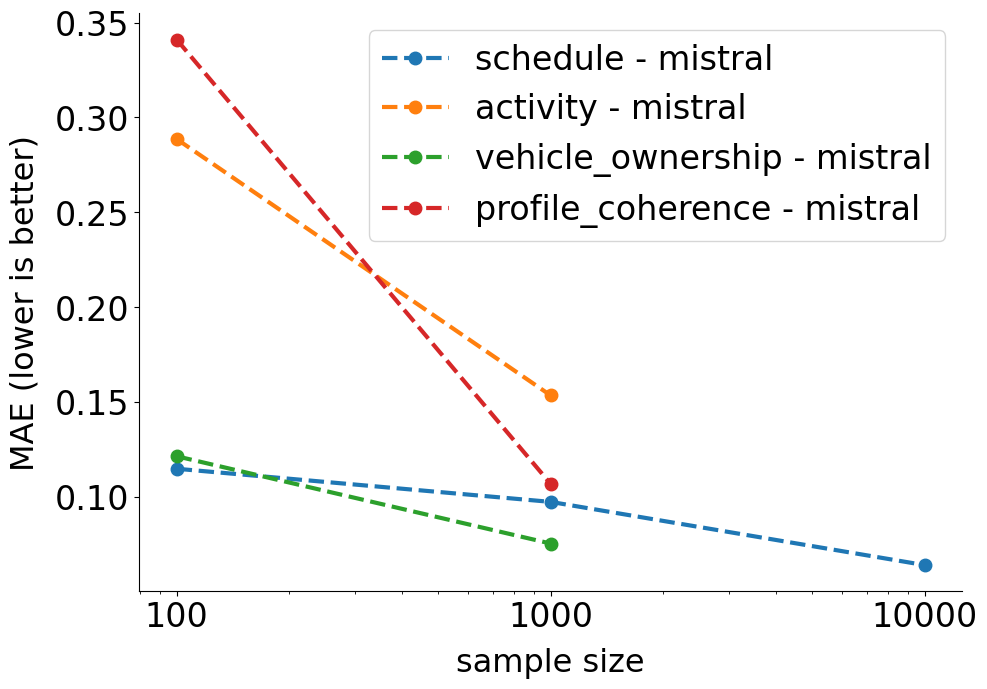

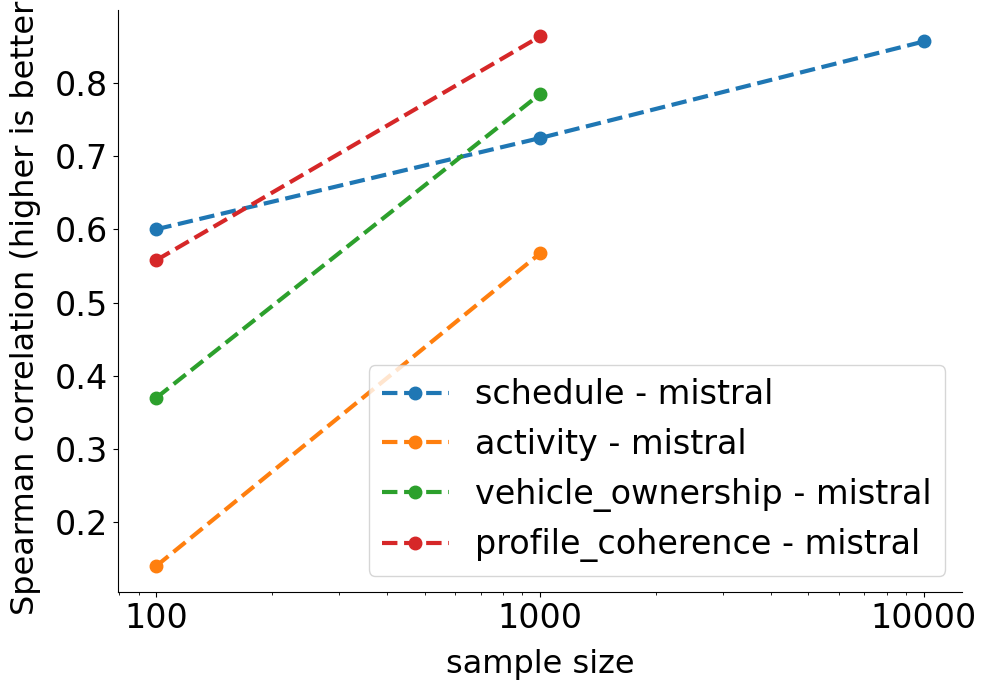

In [14]:
def plot_metric_vs_size(metric, ylabel):
    # Create a single figure and axes (slightly larger base figure can help accommodate bigger text)
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Grab the default matplotlib color palette
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linestyles = ['-', '--', '-.', ':']
    
    for i, aligner in enumerate(ALIGNERS):
        color = colors[i % len(colors)]
        subset = results[results['aligner'] == aligner]
        
        for j, teacher in enumerate(TEACHERS):
            teacher_rows = subset[subset['teacher'] == teacher].sort_values('sample_size')
            if teacher_rows.empty:
                continue
                
            linestyle = linestyles[j % len(linestyles)]
            
            # Combine aligner and teacher in the label for clarity
            label = f"{aligner} - {teacher}"
            
            ax.plot(
                teacher_rows['sample_size'], 
                teacher_rows[metric], 
                marker='o', 
                color=color, 
                linestyle=linestyle,
                label=label,
                linewidth=3,       # Make the lines thicker
                markersize=9       # Make the markers bigger
            )
            
    ax.set_xscale('log')
    ax.set_xticks(SAMPLE_SIZES)
    ax.set_xticklabels(SAMPLE_SIZES)
    
    # Make axis labels bigger
    ax.set_ylabel(ylabel, fontsize=23, labelpad=10)
    ax.set_xlabel('sample size', fontsize=23, labelpad=10)
    
    # Make tick labels bigger
    ax.tick_params(axis='both', which='major', labelsize=24)
    
    # Remove the top and right borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Make the legend bigger
    ax.legend(loc='best', fontsize=24)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{metric}_vs_sample_size.png', dpi=150, bbox_inches='tight')
    plt.show()

# Call your functions
plot_metric_vs_size('mae', 'MAE (lower is better)')
plot_metric_vs_size('spearman', 'Spearman correlation (higher is better)')

## Aligner-specific extras

Profile-coherence: ROC-AUC/PR-AUC separating original vs. mutated profiles, and the
fraction of profiles where the model correctly ranks the original above its mutated
variant. Schedule/activity/vehicle-ownership: per-category MAE breakdown (day_type,
purpose, vehicle respectively) stored as a JSON string per result row.

In [5]:
coherence_extra_cols = ['original_vs_mutated_roc_auc', 'original_vs_mutated_pr_auc', 'paired_original_beats_mutated']
coherence_rows = results[results['aligner'] == 'profile_coherence']
if not coherence_rows.empty:
    display(coherence_rows.set_index(['sample_size', 'teacher'])[coherence_extra_cols].sort_index())

breakdown_cols = {
    'schedule': 'day_type_mae_breakdown',
    'activity': 'purpose_mae_breakdown',
    'vehicle_ownership': 'vehicle_mae_breakdown',
}
for aligner, col in breakdown_cols.items():
    subset = results[results['aligner'] == aligner]
    if subset.empty or col not in subset.columns:
        continue
    print(f'### {aligner}: {col}')
    for _, row in subset.sort_values(['teacher', 'sample_size']).iterrows():
        if pd.isna(row.get(col)):
            continue
        breakdown = json.loads(row[col])
        print(f"  teacher={row['teacher']} n={row['sample_size']}: {breakdown}")


,,original_vs_mutated_roc_auc,original_vs_mutated_pr_auc,paired_original_beats_mutated
sample_size,teacher,,,
100,mistral,0.909091,0.905747,1.0
1000,mistral,0.984375,0.987105,1.0


### schedule: day_type_mae_breakdown
  teacher=mistral n=100: {'weekday': 0.14028002217411997, 'weekend': 0.08940298318862913}
  teacher=mistral n=1000: {'weekday': 0.08629595026373864, 'weekend': 0.10844833850860595}
### activity: purpose_mae_breakdown
  teacher=mistral n=100: {'HOME': 0.2667924928665161, 'OTHER': 0.30615827242533367, 'WORK': 0.3170144557952881}
  teacher=mistral n=1000: {'HOME': 0.16809940611322718, 'OTHER': 0.14027368325520964, 'WORK': 0.13949445039033892}
### vehicle_ownership: vehicle_mae_breakdown
  teacher=mistral n=100: {'bike': 0.13155272006988525, 'car': 0.1113125514984131}
  teacher=mistral n=1000: {'bike': 0.06961126059293747, 'car': 0.08121926051378252}


## Teacher agreement: Qwen vs. Mistral on the identical pairs

Both teachers label the exact same generated pairs (`build_training_pairs` depends only
on the seed, not the teacher), in the same row order, at the largest sample size
(10000). This compares the two teachers directly, independent of any trained model.

schedule: need both teachers labeled at n=10000 to compare (missing one or both).
activity: need both teachers labeled at n=10000 to compare (missing one or both).
vehicle_ownership: need both teachers labeled at n=10000 to compare (missing one or both).
profile_coherence: need both teachers labeled at n=10000 to compare (missing one or both).


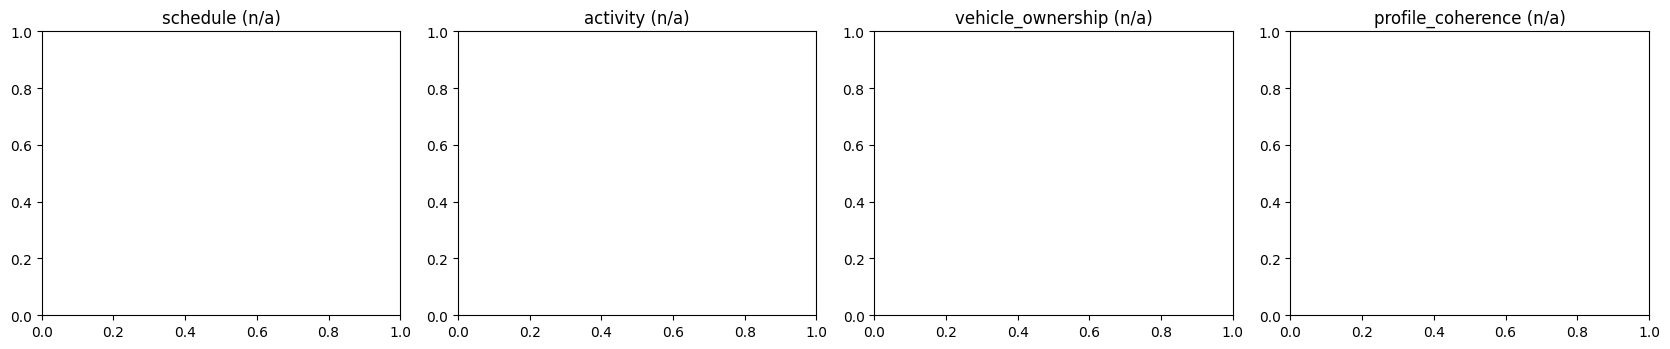

In [6]:
def teacher_agreement(aligner):
    qwen_path = DATA_ROOT / aligner / 'qwen_n10000.parquet'
    mistral_path = DATA_ROOT / aligner / 'mistral_n10000.parquet'
    if not (qwen_path.exists() and mistral_path.exists()):
        print(f'{aligner}: need both teachers labeled at n=10000 to compare (missing one or both).')
        return None
    qwen_df = pd.read_parquet(qwen_path)
    mistral_df = pd.read_parquet(mistral_path)
    if len(qwen_df) != len(mistral_df):
        print(f'{aligner}: row count mismatch ({len(qwen_df)} vs {len(mistral_df)}), skipping.')
        return None
    from scipy.stats import spearmanr
    from sklearn.metrics import mean_absolute_error
    agreement = {
        'n': len(qwen_df),
        'spearman': float(spearmanr(qwen_df['score'], mistral_df['score']).statistic),
        'mae': float(mean_absolute_error(qwen_df['score'], mistral_df['score'])),
    }
    return agreement, qwen_df['score'].to_numpy(), mistral_df['score'].to_numpy()

fig, axes = plt.subplots(1, len(ALIGNERS), figsize=(4.2 * len(ALIGNERS), 3.6))
agreement_rows = []
for ax, aligner in zip(axes, ALIGNERS):
    result = teacher_agreement(aligner)
    if result is None:
        ax.set_title(f'{aligner} (n/a)')
        continue
    agreement, qwen_scores, mistral_scores = result
    agreement['aligner'] = aligner
    agreement_rows.append(agreement)
    ax.scatter(qwen_scores, mistral_scores, alpha=0.25, s=10)
    ax.plot([0, 1], [0, 1], '--', color='black')
    ax.set_title(f"{aligner}\nspearman={agreement['spearman']:.3f}")
    ax.set_xlabel('Qwen score')
    ax.set_ylabel('Mistral score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'teacher_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

if agreement_rows:
    display(pd.DataFrame(agreement_rows).set_index('aligner'))


## Cross-aligner summary and save

In [7]:
summary = results[['aligner', 'teacher', 'sample_size'] + METRIC_COLS].sort_values(
    ['aligner', 'sample_size', 'teacher']
).reset_index(drop=True)
display(summary)
summary.to_csv(OUTPUT_DIR / 'summary_metrics.csv', index=False)
print(f'Saved summary to {OUTPUT_DIR / "summary_metrics.csv"}')


,aligner,teacher,sample_size,n_train,n_test,mae,rmse,spearman,kendall_tau,calibration_mae
0,activity,mistral,100,80,20,0.288647,0.319691,0.140420,0.106664,0.134429
1,activity,mistral,1000,800,200,0.153490,0.215975,0.567037,0.443906,0.041511
2,profile_coherence,mistral,100,80,20,0.341091,0.392392,0.557874,0.407222,0.267436
3,profile_coherence,mistral,1000,800,200,0.106838,0.147616,0.863243,0.703094,0.050307
4,schedule,mistral,100,80,20,0.114842,0.196343,0.600040,0.438640,0.098515
5,schedule,mistral,1000,800,200,0.097372,0.126986,0.724544,0.571836,0.058766
6,vehicle_ownership,mistral,100,80,20,0.121433,0.146598,0.369988,0.286242,0.053103
7,vehicle_ownership,mistral,1000,800,200,0.075415,0.094131,0.784588,0.637789,0.010550


Saved summary to /home/gustavo/citybehavex/notebooks/06_cross_reranker_evaluation/outputs/multi_aligner/summary_metrics.csv
